# L5. Your On-Device Assistant

A day of photos, voice notes, and text notes land in one `EdgeShard`: the kind of day a phone or a pair of smart glasses captures. You build the recall yourself, then ask it your own questions and add your own memories, all offline.

## 1. A day's captures

Photos, voice notes, and text notes from one day. The voice notes are audio until a local speech model turns them into text.

In [1]:
from helper import (day_notes, day_photos, embed_query,
                    embed_query_clip, fresh_start, load_memories,
                    memories_table, memory_inbox, photo_search,
                    remember, show_raw, store_notes,
                    store_photo_memories, text_search,
                    transcribe_notes)

from collections import Counter

memories = load_memories("./ro_shared_data/memories.json")
counts = Counter(m["source_type"] for m in memories)
print(len(memories), "captures:",
      ", ".join(f"{v} {k}" for k, v in sorted(counts.items())))

42 captures: 17 photo, 20 text, 5 voice


In [2]:
from IPython.display import Audio

voice = transcribe_notes(memories, "./ro_shared_data/audio")
print("Heard on-device:", voice[0]["transcript"])
print(len(voice), "voice notes transcribed, all on-device")
Audio(f"./ro_shared_data/audio/{voice[0]['audio_file']}")

Heard on-device: Note to self, the ramen downtown was incredible, $14 and worth it. Sat right by the window.
5 voice notes transcribed, all on-device


## 2. The day at a glance

The photos first, in the order they were taken, then the words that were spoken or typed alongside them.


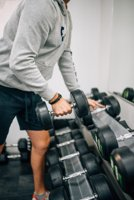
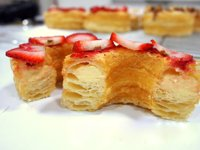
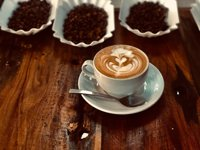
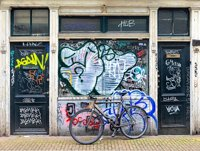
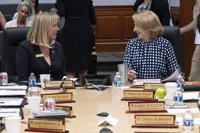
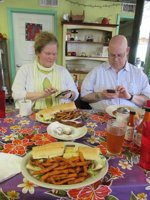
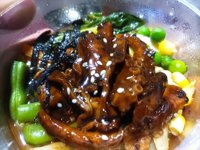
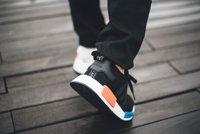
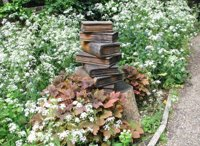
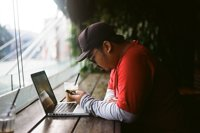
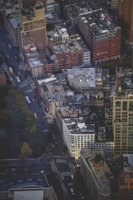
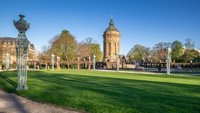
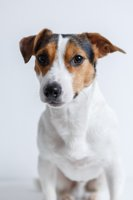
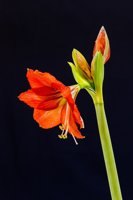
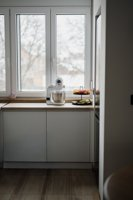
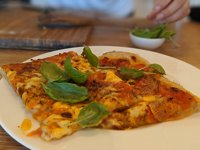
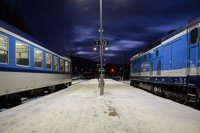

In [3]:
day_photos(memories, "./ro_shared_data/images")

In [4]:
day_notes(memories)

Time,Kind,Note
Nov 13 · 17:00,📝 text,Coffee run to the espresso bar near the office
Nov 13 · 20:00,📝 text,"Late night fixing the deploy pipeline, finally green"
Nov 14 · 07:30,📝 text,"Renewed the gym membership, locker code is 4471"
Nov 14 · 08:00,📝 text,New bakery on the corner does an amazing morning cronut
Nov 14 · 08:18,📝 text,Great little coffee place on 5th with outdoor seating and fast wifi
Nov 14 · 09:00,📝 text,"Pick up dry cleaning before Friday, ticket is on the fridge"
Nov 14 · 09:12,🎙️ voice,"Park the bike near the station, second rack from the entrance."
Nov 14 · 10:00,📝 text,Standup with Sarah moved to Thursday to review the Q3 roadmap
Nov 14 · 10:06,🎙️ voice,"Quick memo, the standup is moved to Thursday. Tell the rest of the team."
Nov 14 · 11:30,📝 text,Idea: batch the weekly report so it drafts itself every Monday


## 3. Set up the day's shard

In [5]:
from qdrant_edge import (Distance, EdgeConfig, EdgeShard,
                         EdgeVectorParams)

SHARD_DIR = fresh_start("./day_shard")

config = EdgeConfig(
    vectors={
        "text": EdgeVectorParams(size=768, distance=Distance.Cosine),
        "image": EdgeVectorParams(size=512, distance=Distance.Cosine),
    }
)
shard = EdgeShard.create(SHARD_DIR, config)
print("Shard ready: text 768-d (Nomic), image 512-d (CLIP)")

Shard ready: text 768-d (Nomic), image 512-d (CLIP)


## 4. Store the day

Two writes: notes into the text vector, photos into the image vector. Both repeat the store Lesson 2 taught.

In [6]:
texts = [m for m in memories if m["source_type"] in ("text", "voice")]
store_notes(shard, texts)
memories_table(texts[:5], "A few of the notes now in memory")

Stored 25 notes


Category,Memory
food,Great little coffee place on 5th with outdoor seating and fast wifi
work,Standup with Sarah moved to Thursday to review the Q3 roadmap
errands,"Pick up dry cleaning before Friday, ticket is on the fridge"
work,Idea: batch the weekly report so it drafts itself every Monday
social,"Mum's new address is 14 Elm Court, buzzer 3"


Stored 17 photos. Total: 42 memories



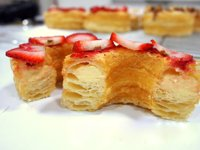
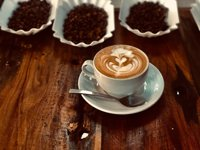
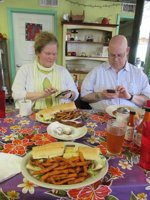
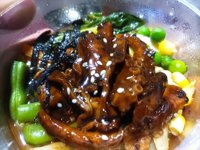
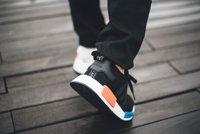
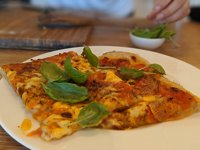

In [7]:
photos = [m for m in memories if m["source_type"] == "photo"]
store_photo_memories(shard, photos, "./ro_shared_data/images")
day_photos(photos[:6], "./ro_shared_data/images")

## 5. Inspect a stored point

In [8]:
from qdrant_edge import ScrollRequest

records, _ = shard.scroll(
    ScrollRequest(limit=1, with_payload=True, with_vector=True)
)
p = records[0]
vector = p.vector["text"]
print("id:", p.id)
print("text vector:", [round(x, 3) for x in vector[:6]],
      f"... {len(vector)} numbers")
print("payload:", p.payload)

id: 0
text vector: [-0.035, 0.027, -0.221, -0.011, 0.004, -0.014] ... 768 numbers
payload: {'id': 0, 'source_type': 'text', 'category': 'food', 'location': '5th St', 'timestamp': 1699949880, 'note': 'Great little coffee place on 5th with outdoor seating and fast wifi'}


## 6. How recall works

One question becomes two vectors, one per space. Each lane searches its own vector, then the lanes merge into an inbox.

In [9]:
def recall(question):
    # fetch extra text hits so one lane cannot crowd out the other
    text_hits = text_search(shard, question, limit=10)
    photo_hits = photo_search(shard, question, limit=1)
    return {
        "Photos": photo_hits,
        "Voice Notes": [h for h in text_hits
                        if h.payload["source_type"] == "voice"][:3],
        "Text Notes": [h for h in text_hits
                       if h.payload["source_type"] == "text"][:3],
    }


print("one question becomes two vectors:",
      len(embed_query("ramen")), "d Nomic for text ·",
      len(embed_query_clip("ramen")), "d CLIP for photos")

one question becomes two vectors: 768 d Nomic for text · 512 d CLIP for photos


## 7. Your turn: recall your day

Lane,Score,id,Memory
Photos,0.247,28,ramen.jpg
Voice Notes,0.809,20,"Note to self, the ramen downtown was incredible, $14 and wor"
Voice Notes,0.442,23,"Park the bike near the station, second rack from the entranc"
Voice Notes,0.428,22,"Quick memo, the standup is moved to Thursday. Tell the rest"
Text Notes,0.786,8,"Try the new ramen place downtown, everyone raves about the t"
Text Notes,0.513,0,Great little coffee place on 5th with outdoor seating and fa
Text Notes,0.473,18,Coffee run to the espresso bar near the office



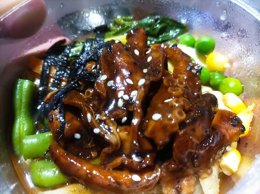

In [10]:
# Change my_question and re-run. Try: "where did I park the bike",
# "gym locker code", "when is the dentist".
my_question = "the ramen place downtown"

hits = recall(my_question)
display(show_raw(hits))
memory_inbox(hits, "./ro_shared_data/images", min_score=0.6)

## 8. Add your own memory, then recall it

Lane,Score,id,Memory
Photos,0.213,31,bicycle.jpg
Voice Notes,0.475,23,"Park the bike near the station, second rack from the entranc"
Voice Notes,0.468,24,"Just remember, we are low on coffee at home. Grab a bag on t"
Voice Notes,0.411,20,"Note to self, the ramen downtown was incredible, $14 and wor"
Text Notes,0.757,900,Left the spare key with the neighbor in apartment 4B
Text Notes,0.457,10,"Renewed the gym membership, locker code is 4471"
Text Notes,0.442,12,Remember to call the landlord about the leaking tap



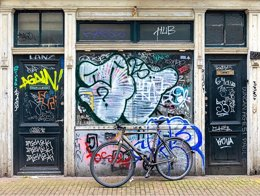

In [11]:
# Add your own memory, then ask for it. Change both together!
my_note = "Left the spare key with the neighbor in apartment 4B"
my_question = "where did I leave the spare key"

remember(shard, my_note, memories)

hits = recall(my_question)
display(show_raw(hits))
memory_inbox(hits, "./ro_shared_data/images", min_score=0.6)